# Práctica PLN: Filtro Automatizado de Talento (HR Tech)
Este notebook implementa un sistema de 'Screening' que compara la descripción de una oferta de trabajo con miles de CVs y puntúa cuáles son los candidatos más afines mediante similitud semántica.

**Objetivo de Negocio**: Optimizar el proceso de reclutamiento reduciendo el tiempo de pre-selección de candidatos.

## 1. Importación de Librerías

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
import nltk
from nltk.corpus import stopwords
from langdetect import detect, DetectorFactory
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Aseguramos resultados reproducibles para el detector de idioma
DetectorFactory.seed = 0
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

## 2. Carga de Datos
Cargamos el dataset de currículos obtenido de Kaggle.

In [19]:
df = pd.read_csv('resume_data.csv')
print(f'Total de currículos cargados: {len(df)}')
df.head()

Total de currículos cargados: 9544


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


## 3. Análisis Exploratorio de Datos (EDA) Exhaustivo
Realizamos un análisis profundo del dataset para entender su estructura y contenido.

### 3.1 Valores Nulos
Verificamos si existen celdas vacías en las columnas clave para el filtrado.

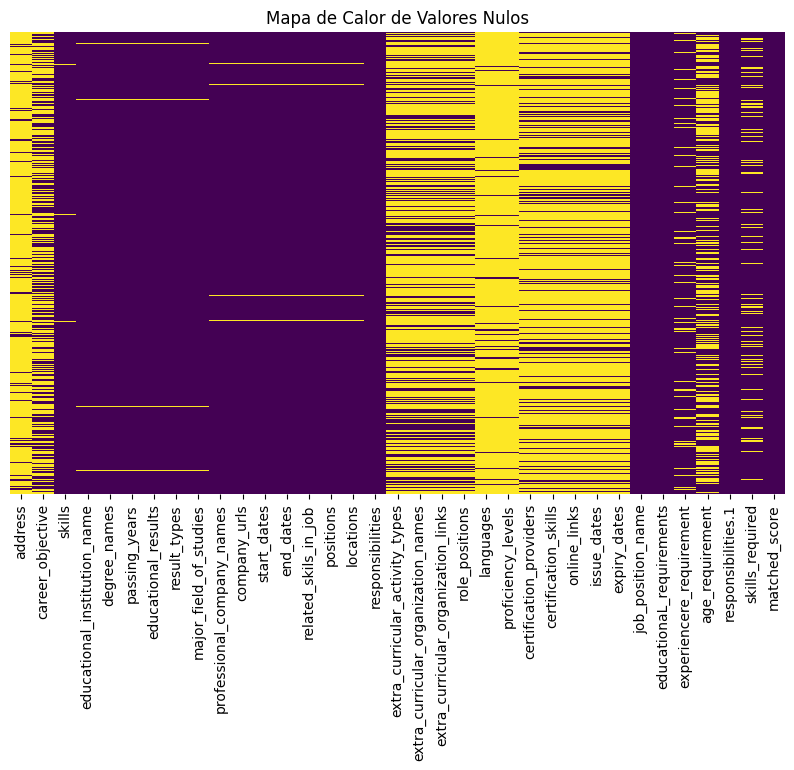

Resumen de valores nulos por columna:
address                                8760
career_objective                       4804
skills                                   56
educational_institution_name             84
degree_names                             84
passing_years                            84
educational_results                      84
result_types                             84
major_field_of_studies                   84
professional_company_names               84
company_urls                             84
start_dates                              84
end_dates                                84
related_skils_in_job                     84
positions                                84
locations                                84
responsibilities                          0
extra_curricular_activity_types        6118
extra_curricular_organization_names    6118
extra_curricular_organization_links    6118
role_positions                         6118
languages                             

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos')
plt.show()

print('Resumen de valores nulos por columna:')
print(df.isnull().sum())

### 3.2 Distribución de Categorías / Puestos
Analizamos qué tipos de candidatos predominan en nuestra base de datos.

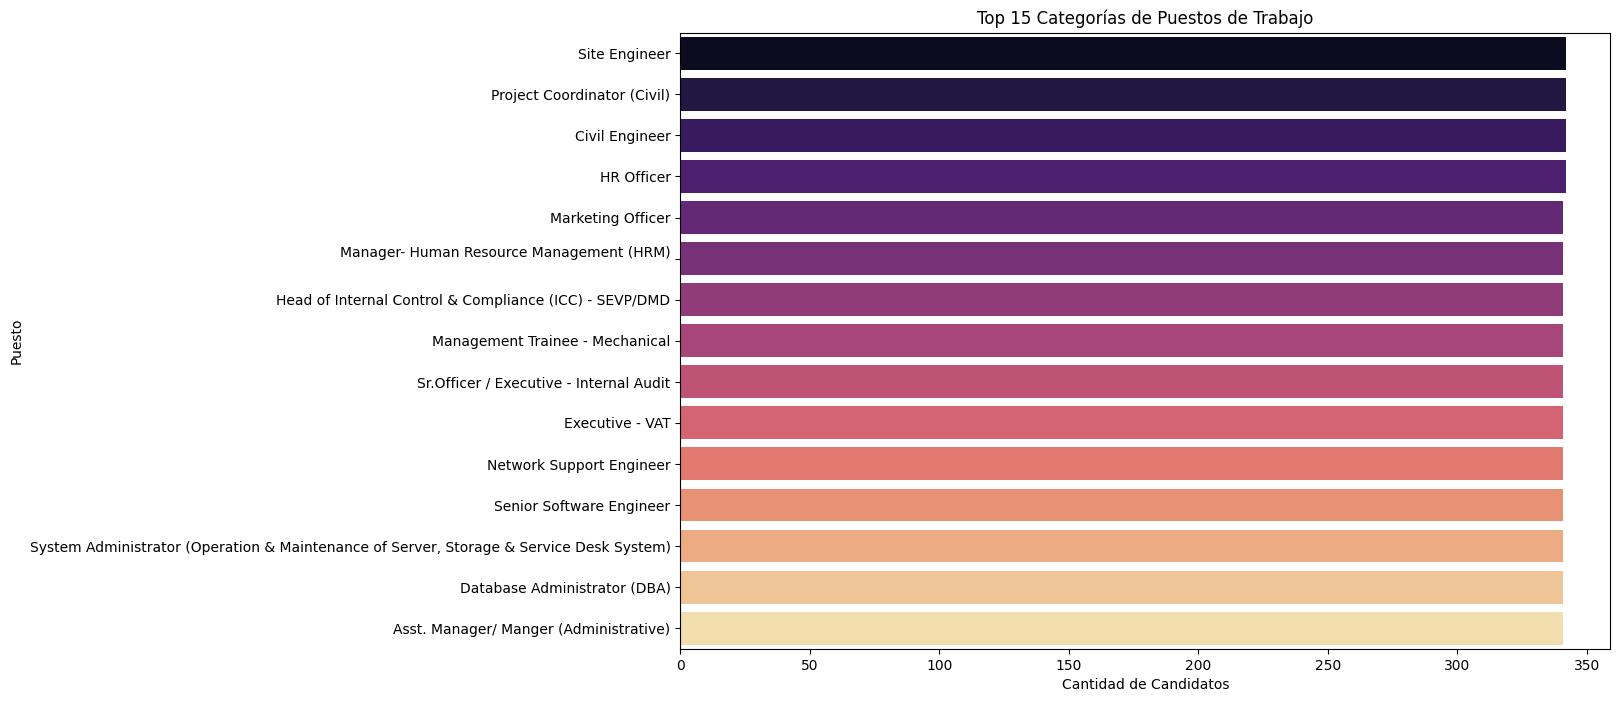

In [21]:
pos_col = [c for c in df.columns if 'job_position_name' in c][0]
plt.figure(figsize=(12, 8))
top_positions = df[pos_col].value_counts().index[:15]
sns.countplot(y=df[pos_col], order=top_positions, palette='magma')
plt.title('Top 15 Categorías de Puestos de Trabajo')
plt.xlabel('Cantidad de Candidatos')
plt.ylabel('Puesto')
plt.show()

### 3.3 Análisis de Longitud de los Currículos
Estudiamos la extensión de los textos para ver qué tan detallados son los CVs.

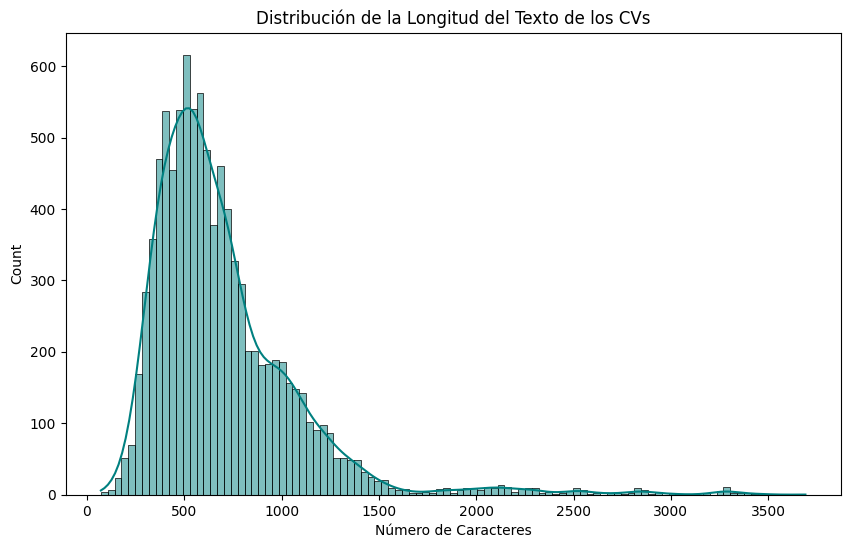

Longitud media de los CVs: 699.10 caracteres


In [22]:
df['resume_len'] = df['career_objective'].fillna('').apply(len) + df['skills'].fillna('').apply(len) + df['responsibilities'].fillna('').apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df['resume_len'], kde=True, color='teal')
plt.title('Distribución de la Longitud del Texto de los CVs')
plt.xlabel('Número de Caracteres')
plt.show()

print(f'Longitud media de los CVs: {df["resume_len"].mean():.2f} caracteres')

### 3.4 Visualización de Nubes de Palabras (WordClouds)
Identificamos las palabras clave más frecuentes en los currículos.

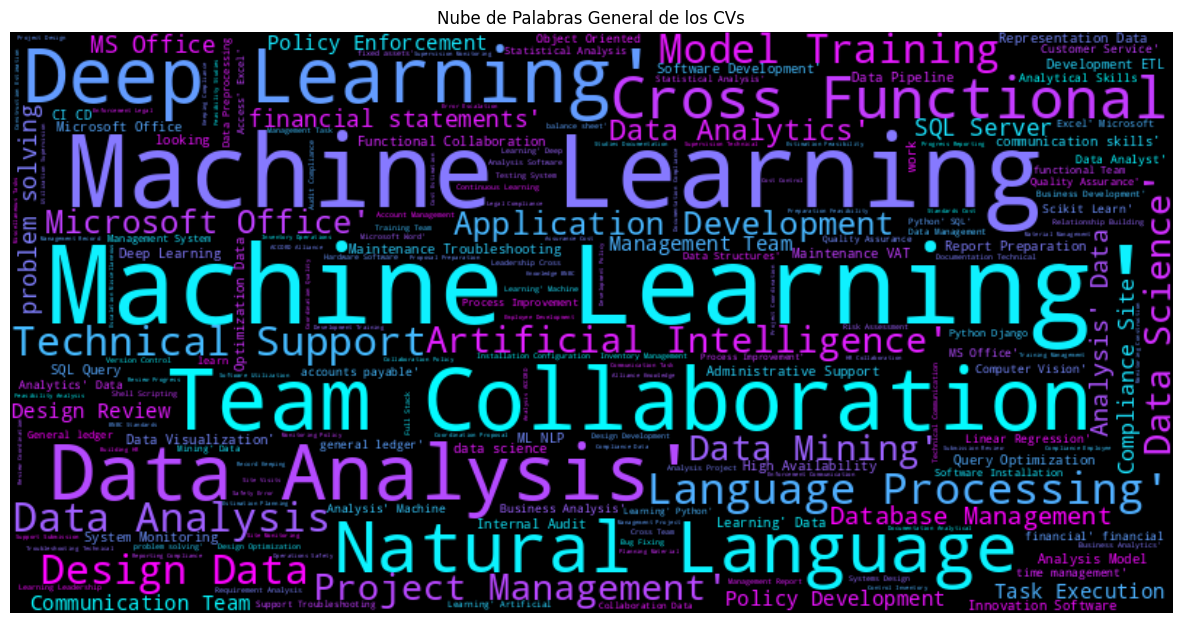

In [23]:
from wordcloud import WordCloud

text_all = ' '.join(df['career_objective'].fillna('') + ' ' + df['skills'].fillna('') + ' ' + df['responsibilities'].fillna(''))
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='cool').generate(text_all)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras General de los CVs')
plt.show()

### 3.5 Nubes de Palabras por Categoría (Top 3)
Comparamos los términos más usados en diferentes roles para verificar la diferenciación semántica.

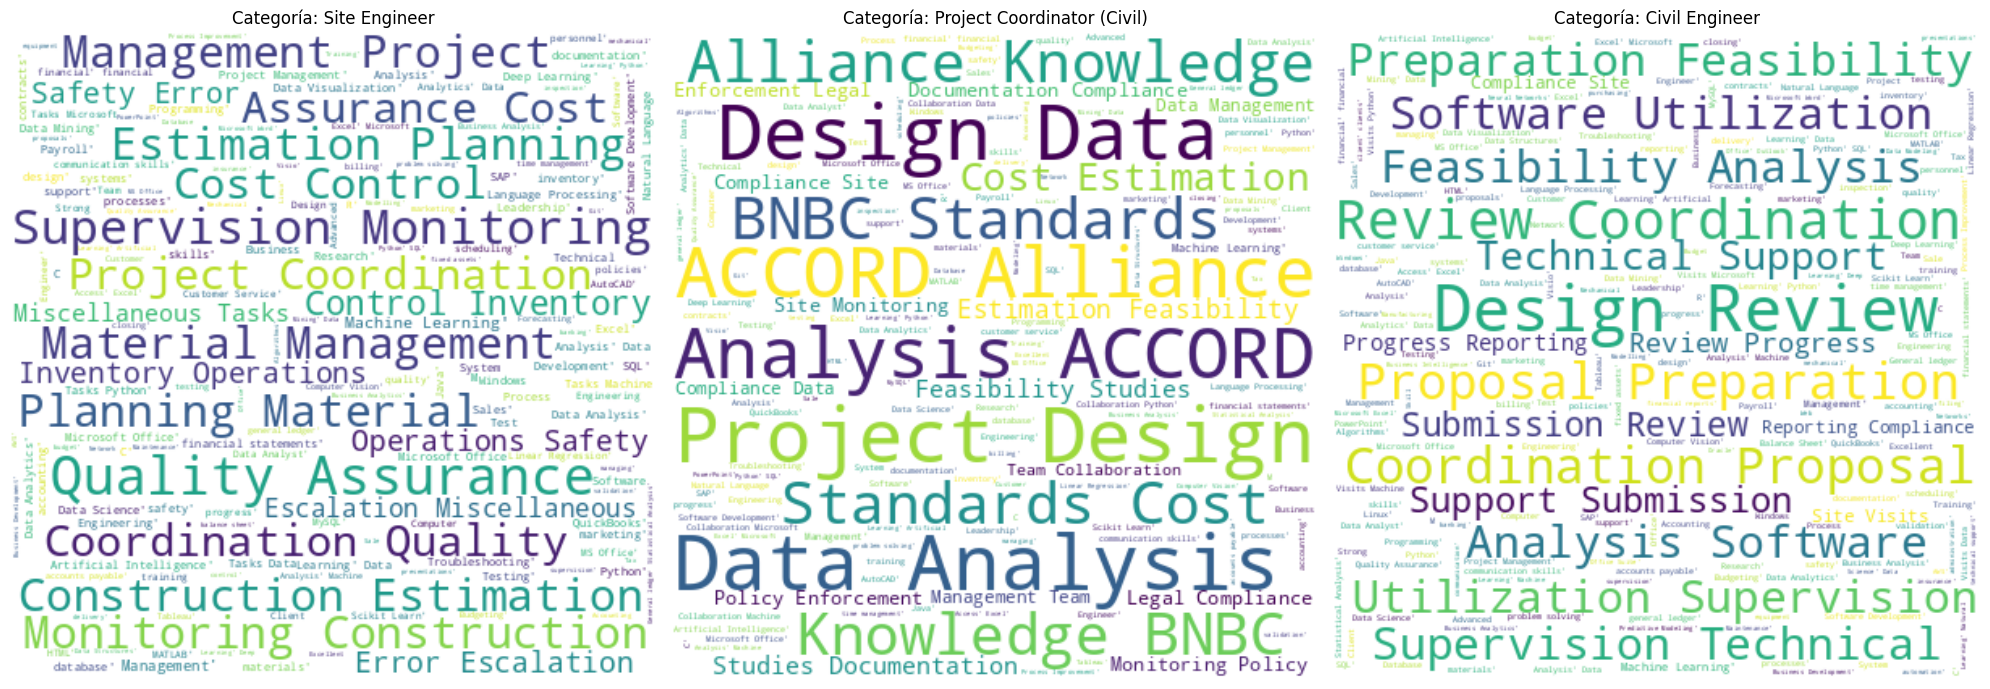

In [24]:
top_3_cats = df[pos_col].value_counts().index[:3]
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for i, cat in enumerate(top_3_cats):
    cat_text = ' '.join(df[df[pos_col] == cat]['skills'].fillna('') + ' ' + df[df[pos_col] == cat]['responsibilities'].fillna(''))
    wc = WordCloud(width=400, height=400, background_color='white').generate(cat_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Categoría: {cat}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### 3.6 Análisis de Calidad de Datos
Evaluamos la integridad y limpieza de los datos para asegurar la fiabilidad del modelo.

#### 3.6.2 Consistencia de Idioma
Verificamos si todos los currículos están en el mismo idioma.

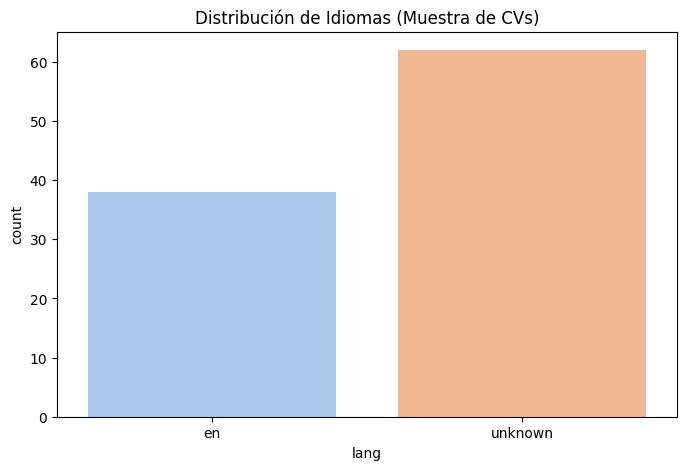

In [26]:
from langdetect import detect
def get_lang(text):
    try:
        if len(text.strip()) < 10: return 'unknown'
        return detect(text)
    except: return 'unknown'

df_sample_lang = df.sample(100) if len(df) > 100 else df
df_sample_lang['lang'] = df_sample_lang['career_objective'].fillna('').apply(get_lang)
plt.figure(figsize=(8, 5))
sns.countplot(x='lang', data=df_sample_lang, palette='pastel')
plt.title('Distribución de Idiomas (Muestra de CVs)')
plt.show()

#### 3.6.3 Densidad de Caracteres Especiales (Ruido)
Una alta densidad de caracteres no alfanuméricos puede indicar problemas de extracción de texto.

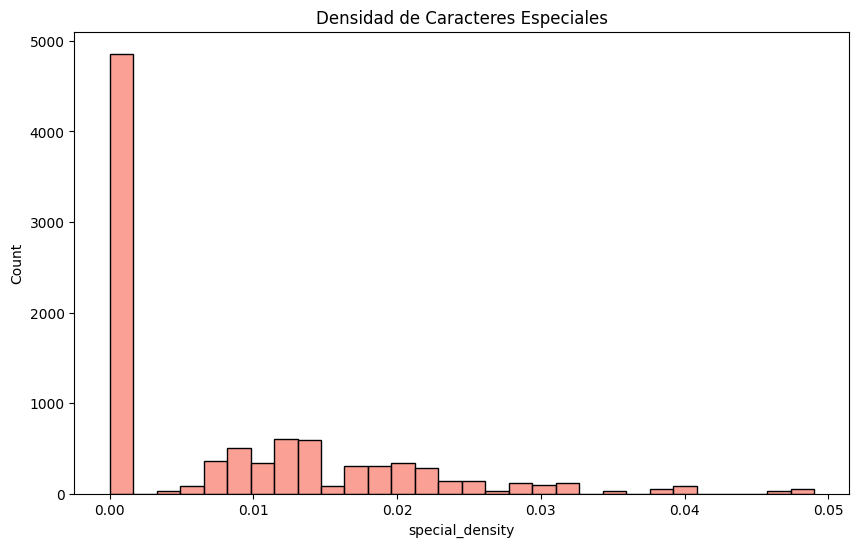

Densidad media de caracteres especiales: 0.0083


In [27]:
def special_char_density(text):
    if not text or len(text) == 0: return 0
    special_chars = len(re.sub(r'[\w\s]', '', text))
    return special_chars / len(text)

df['special_density'] = df['career_objective'].fillna('').apply(special_char_density)
plt.figure(figsize=(10, 6))
sns.histplot(df['special_density'], bins=30, color='salmon')
plt.title('Densidad de Caracteres Especiales')
plt.show()

print(f'Densidad media de caracteres especiales: {df["special_density"].mean():.4f}')

#### 3.6.4 Amplitud de Vocabulario
Medimos la riqueza léxica de los currículos (un CV muy pobre puede no ser útil).

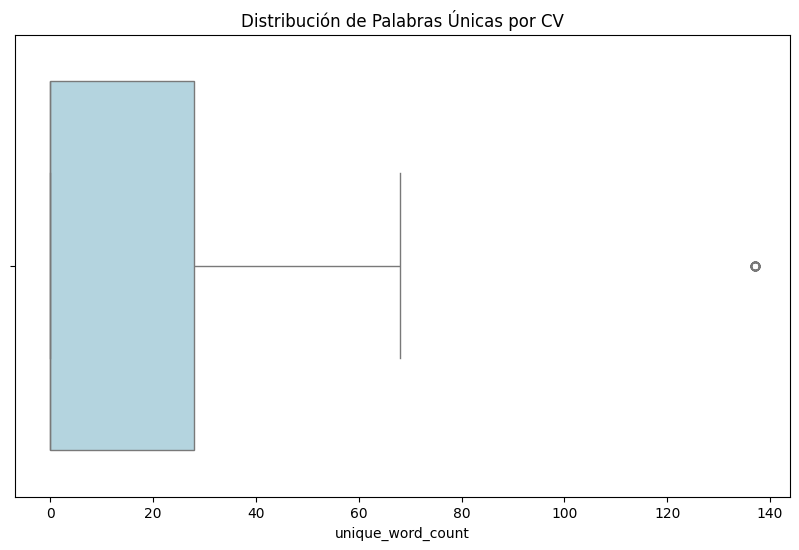

In [28]:
df['unique_word_count'] = df['career_objective'].fillna('').apply(lambda x: len(set(x.lower().split())))
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['unique_word_count'], color='lightblue')
plt.title('Distribución de Palabras Únicas por CV')
plt.show()

## 4. Limpieza y Refinamiento de Datos (Basado en EDA)
Aplicamos las correcciones identificadas durante el análisis de calidad para mejorar la precisión del modelo.

### 4.1 Eliminación de Duplicados
Identificamos y removemos registros que sean exactamente iguales para evitar sesgos en el modelo.

In [29]:
# 1. Eliminación de Duplicados
initial_len = len(df)
df.drop_duplicates(inplace=True)
print(f'Registros eliminados por duplicidad exacta: {initial_len - len(df)}')
print(f'Registros tras eliminar duplicados: {len(df)}')

Registros eliminados por duplicidad exacta: 0
Registros tras eliminar duplicados: 9544


Se han aplicado un filtro de longitud mínima. Si un extracto profesional tiene menos de 10 caracteres, se considera "ruido" o dato incompleto y se descarta, ya que no proporciona suficiente contexto semántico para que el modelo SBERT pueda trabajar bien.

In [30]:
# 2. Filtrado por Idioma y Calidad
def is_english(text):
    if len(str(text)) < 20: return False
    try:
        return detect(text) == 'en'
    except:
        return False

print('Detectando idioma (esto puede tardar un poco)...')
df = df[df['career_objective'].fillna('').apply(is_english)]
print(f'Registros tras filtrado por idioma (Inglés): {len(df)}')

Detectando idioma (esto puede tardar un poco)...
Registros tras filtrado por idioma (Inglés): 4740


## 4.2 Preprocesamiento de Texto


Se ha creado una nueva variable llamada resume_content que concatena los campos de Objetivo Profesional, Habilidades y Responsabilidades. Esto permite que el modelo tenga una visión "360" de la experiencia del candidato en un solo vector.

In [31]:
def safe_parse_list(text):
    """Convierte strings tipo list ['a', 'b'] en texto plano 'a b'"""
    if pd.isna(text) or text == '': return ''
    if str(text).startswith('['):
        try:
            vals = ast.literal_eval(text)
            return ' '.join(vals)
        except: 
            return str(text)
    return str(text)

def clean_text(text):
    if pd.isna(text): return ''
    # 1. Parsear listas si existen
    text = safe_parse_list(text)
    # 2. Eliminar URLs, emails y números de teléfono
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S*@\S*\s?', '', text) # Emails
    text = re.sub(r'\+?\d[\d -]{8,12}\d', '', text) # Teléfonos aproximados
    # 3. Limpieza de caracteres especiales y números
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # 4. Tokenización y Stopwords
    text = text.lower().strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

# Aplicamos la limpieza combinada
df['resume_content'] = (
    df['career_objective'].fillna('') + ' ' + 
    df['skills'].apply(safe_parse_list) + ' ' + 
    df['responsibilities'].fillna('')
)
df['resume_content'] = df['resume_content'].apply(clean_text)

print('Ejemplo de contenido procesado (mejorado):')
print(df['resume_content'].iloc[0][:500])

Ejemplo de contenido procesado (mejorado):
big data analytics working database warehouse manager robust experience handling kinds data also used multiple cloud infrastructure services well acquainted currently search role offers development big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science data structures dbms rdbms informatica talend amazon redshift microsoft azure technical support troubleshooting collaboration documentation system monitoring software deployment training mentorship


## 5. Modelado con Sentence-BERT
Utilizamos un modelo pre-entrenado de SBERT para convertir los textos en vectores (embeddings).

In [32]:
# Cargamos el modelo (ligero y eficiente)
model_name = 'all-MiniLM-L6-v2'
model = SentenceTransformer(model_name)

# Generamos embeddings para todos los currículos (limitamos a 1000 para la PoC rápida si es necesario)
df_poc = df.head(1000)
print('Generando embeddings para los currículos...')
resume_embeddings = model.encode(df_poc['resume_content'].tolist(), show_progress_bar=True)

Generando embeddings para los currículos...


Batches: 100%|██████████| 32/32 [00:39<00:00,  1.23s/it]


## 6. Sistema de Screening (Búsqueda Semántica)
Definimos una función que tome una oferta de trabajo y devuelva los candidatos más afines.

In [33]:
def get_top_candidates(job_description, top_n=5):
    # Codificar la descripción de la oferta
    job_embedding = model.encode([job_description])
    # Calcular similitud coseno
    cosine_scores = util.cos_sim(job_embedding, resume_embeddings)[0]
    # Obtener los índices de los mejores scores
    top_results_indices = np.argsort(-cosine_scores)[:top_n]

    # Robustly find the job position column
    pos_col = [c for c in df_poc.columns if 'job_position_name' in c][0]

    results = []
    for idx in top_results_indices:
        results.append({
            'ID': idx.item(),
            'Puesto': df_poc.iloc[idx.item()][pos_col],
            'Score': round(float(cosine_scores[idx]), 4)
        })
    return pd.DataFrame(results)

# Ejemplo: Buscamos un analista de Big Data con experiencia en Python
job_desc = 'We are looking for a Big Data Analyst with experience in Python, Hadoop, and SQL. Ability to handle large datasets and Cloud infrastructure.'
top_candidates = get_top_candidates(job_desc)
print('Top Candidatos encontrados:')
print(top_candidates)

Top Candidatos encontrados:
    ID                                             Puesto   Score
0  338                        Project Coordinator (Civil)  0.6586
1    0                           Senior Software Engineer  0.6553
2  141  Executive/ Senior Executive- Trade Marketing, ...  0.6502
3  826                                  Marketing Officer  0.6347
4  155                                         HR Officer  0.6330


## 7. Visualización de Resultados
Mostramos los resultados de forma visual para el departamento de RRHH.

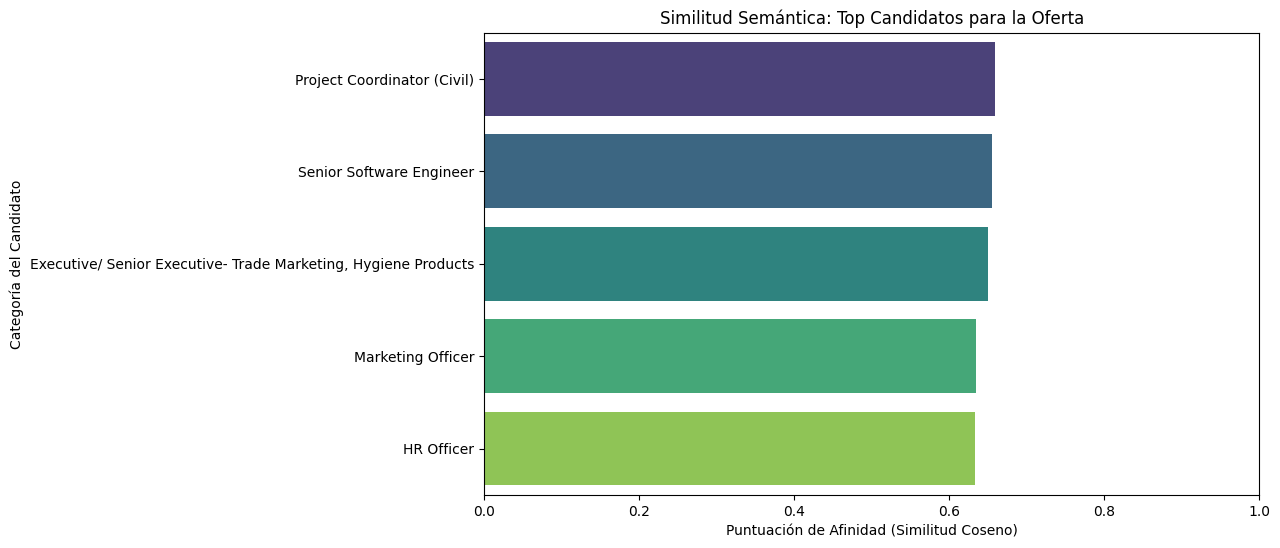

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Puesto', data=top_candidates, palette='viridis')
plt.title('Similitud Semántica: Top Candidatos para la Oferta')
plt.xlabel('Puntuación de Afinidad (Similitud Coseno)')
plt.ylabel('Categoría del Candidato')
plt.xlim(0, 1)
plt.show()

## 8. Conclusiones y Sentido de Negocio
- El modelo **SBERT** permite capturar el significado semántico más allá de las palabras clave exactas.
- Esta herramienta puede **ahorrar cientos de horas** de revisión manual en departamentos de RRHH.
- Para una versión de producción, se podrían añadir filtros por ubicación, lenguajes y años de experiencia.